Parallelisation sur 2 cœurs (/2 disponibles)

=== n=100, p=100 ===


  a loop (n=100,p=100): 100%|██████████| 100/100 [03:13<00:00,  1.93s/it]



=== n=100, p=500 ===


  a loop (n=100,p=500): 100%|██████████| 100/100 [16:08<00:00,  9.68s/it]



=== n=100, p=1000 ===


...

  a loop (n=500,p=100): 100%|██████████| 100/100 [07:45<00:00,  4.66s/it]



=== n=500, p=500 ===


  a loop (n=500,p=500): 100%|██████████| 100/100 [43:29<00:00, 26.09s/it]



=== n=500, p=1000 ===


  a loop (n=500,p=1000): 100%|██████████| 100/100 [3:22:50<00:00, 121.70s/it]


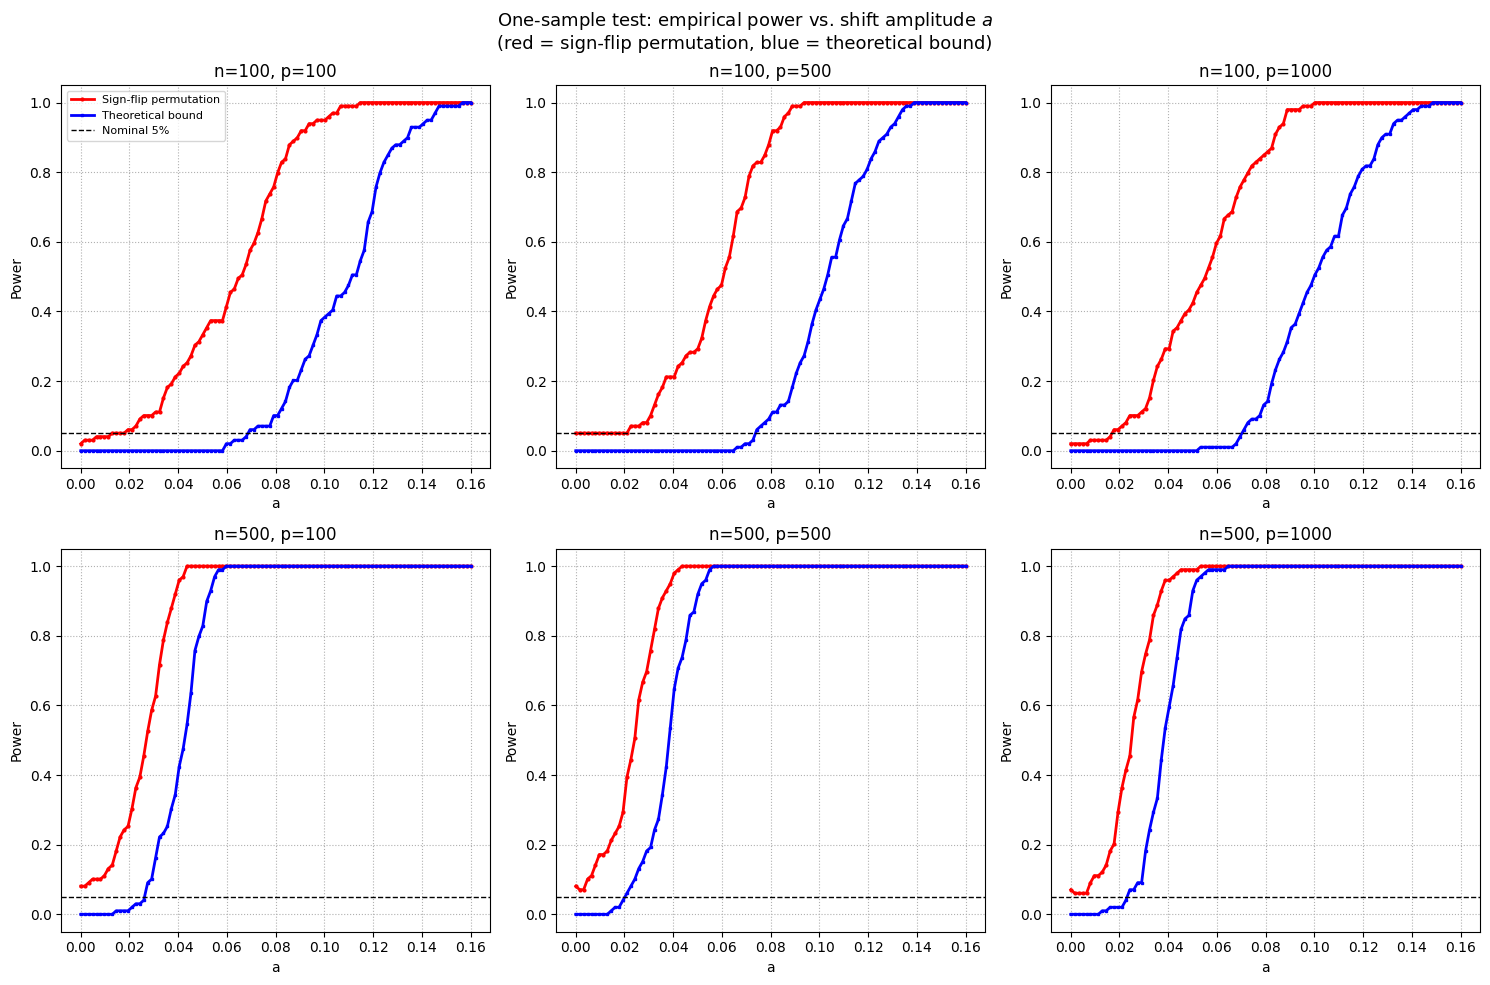

Graphiques sauvegardés.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from tqdm import tqdm
from joblib import Parallel, delayed
import multiprocessing

# ============================================================================
# Paramètres fixes
# ============================================================================
n_basis     = 10
sigma_noise = 0.05
sigma_coeff = 1.0
alpha       = 1.0
B           = 199
M           = 99
a_grid      = np.linspace(0, 0.16, 100)

n_vals = [100, 500]
p_vals = [100, 500, 1000]

N_JOBS = max(2, multiprocessing.cpu_count() - 1)
print(f"Parallelisation sur {N_JOBS} cœurs (/{multiprocessing.cpu_count()} disponibles)")

def get_t(p):
    return (np.arange(1, p + 1) - 0.5) / p

# ============================================================================
# Génération des courbes
# ============================================================================
def generate_curves(mean_func, n_curves, t, n_basis, sigma_noise, seed, sigma_coeff):
    np.random.seed(seed)
    basis = []
    for k in range(1, n_basis + 1):
        basis.append(0.25 * np.sin(np.pi * k * t))
        basis.append(0.25 * np.cos(np.pi * k * t))
    basis = np.array(basis).T
    mu     = mean_func(t)
    curves = np.zeros((n_curves, len(t)))
    for i in range(n_curves):
        coeff     = np.random.normal(0, sigma_coeff, size=2 * n_basis)
        noise     = np.random.normal(0, sigma_noise, size=len(t))
        curves[i] = mu + basis @ coeff + noise
    return curves

def mean_null(t):
    return np.zeros_like(t)

def mean_const(t, a):
    return a * np.ones_like(t)

# ============================================================================
# Statistique T^2
# ============================================================================
def compute_T2_fixed_alpha(Z, alpha):
    n, p    = Z.shape
    Gamma_n = (Z.T @ Z) / n
    k_max   = min(n, p)
    eigvals_all, eigvecs_all = eigh(Gamma_n, subset_by_index=[p - k_max, p - 1])
    idx     = np.argsort(eigvals_all)[::-1]
    eigvals = eigvals_all[idx]
    eigvecs = eigvecs_all[:, idx]
    U       = Z @ eigvecs
    S       = np.sum(U, axis=0)
    denom   = n * (eigvals + alpha)
    T2      = np.sum((S**2) / denom)
    return T2, eigvals, eigvecs, U, denom

# ============================================================================
# Borne théorique
# ============================================================================
def theoretical_bound(eigvals, alpha, delta=0.05):
    C         = (2.0 / 9.0) * np.exp(3)
    c         = np.log(C / delta)
    ratios    = eigvals / (eigvals + alpha)
    Theta1    = np.sum(ratios)
    Theta2    = np.sqrt(np.sum(ratios**2))
    Theta_inf = np.max(ratios)
    return Theta1 + 2 * Theta2 * (np.sqrt(c) + (Theta_inf / Theta2) * c)

# ============================================================================
# Référence sous H0 pour la borne (une fois par (n,p))
# ============================================================================
def get_ref_data(n, p):
    t     = get_t(p)
    Z_ref = generate_curves(mean_null, n, t, n_basis, sigma_noise,
                            seed=12345, sigma_coeff=sigma_coeff)
    return Z_ref, t

# ============================================================================
# Fonction exécutée en parallèle : une réplication Monte Carlo
# ============================================================================
def one_replication(rep, a, n, p, t, Z_ref, alpha, B):
    """
    Retourne (rej_perm, rej_bound, T_obs) pour une réplication.
    Tout est auto-contenu — pas d'état partagé.
    """
    # --- données ---
    W = generate_curves(lambda t, a=a: mean_const(t, a),
                        n, t, n_basis, sigma_noise,
                        seed=rep, sigma_coeff=sigma_coeff)
    Z = W

    # --- T^2 observé ---
    T_obs, eigvals, eigvecs, U, denom = compute_T2_fixed_alpha(Z, alpha)

    # --- borne théorique (eigvals du Z_ref sous H0) ---
    _, eigvals_ref, _, _, _ = compute_T2_fixed_alpha(Z_ref, alpha)
    bound = theoretical_bound(eigvals_ref, alpha, delta=0.05)
    rej_bound = int(T_obs >= bound)

    # --- sign-flip permutation ---
    rng    = np.random.default_rng(rep + 999999)   # RNG propre à chaque rep
    T_perm = np.zeros(B)
    for b in range(B):
        signs     = rng.choice([-1, 1], size=n)
        S_perm    = (signs[:, None] * U).sum(axis=0)
        T_perm[b] = np.sum(S_perm**2 / denom)
    p_val    = (1 + np.sum(T_perm >= T_obs)) / (B + 1)
    rej_perm = int(p_val < 0.05)

    return rej_perm, rej_bound, T_obs

# ============================================================================
# Boucle principale — parallélisation sur les réplications Monte Carlo
# ============================================================================
power_perm_results  = {}
power_bound_results = {}
T2_mean_results     = {}

for n in n_vals:
    for p in p_vals:
        print(f"\n=== n={n}, p={p} ===")
        t     = get_t(p)
        Z_ref, _ = get_ref_data(n, p)

        power_perm_a  = np.zeros(len(a_grid))
        power_bound_a = np.zeros(len(a_grid))
        T2_mean_a     = np.zeros(len(a_grid))

        for i, a in enumerate(tqdm(a_grid, desc=f"  a loop (n={n},p={p})")):

            # ---- appel parallèle sur les M réplications ----
            results = Parallel(n_jobs=N_JOBS, backend='loky')(
                delayed(one_replication)(rep, a, n, p, t, Z_ref, alpha, B)
                for rep in range(M)
            )
            # results : liste de (rej_perm, rej_bound, T_obs)
            rp, rb, t2 = zip(*results)

            power_perm_a[i]  = np.mean(rp)
            power_bound_a[i] = np.mean(rb)
            T2_mean_a[i]     = np.mean(t2)

        power_perm_results[(n, p)]  = power_perm_a
        power_bound_results[(n, p)] = power_bound_a
        T2_mean_results[(n, p)]     = T2_mean_a

# ============================================================================
# Figure : puissance (2 lignes × 3 colonnes)
# ============================================================================
fig1, axes1 = plt.subplots(len(n_vals), len(p_vals), figsize=(15, 10))
for i, n in enumerate(n_vals):
    for j, p in enumerate(p_vals):
        ax = axes1[i, j]
        ax.plot(a_grid, power_perm_results[(n, p)],
                'r-o', linewidth=2, markersize=2, label='Sign-flip permutation')
        ax.plot(a_grid, power_bound_results[(n, p)],
                'b-s', linewidth=2, markersize=2, label='Theoretical bound')
        ax.axhline(y=0.05, color='k', linestyle='--', linewidth=1, label='Nominal 5%')
        ax.set_title(f'n={n}, p={p}')
        ax.set_xlabel('a')
        ax.set_ylabel('Power')
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, linestyle=':')
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.suptitle(
    'One-sample test: empirical power vs. shift amplitude $a$\n'
    '(red = sign-flip permutation, blue = theoretical bound)',
    fontsize=13
)
plt.tight_layout()
plt.savefig('one_sample_power_vs_a.pdf')
plt.savefig('one_sample_power_vs_a.png', dpi=150)
plt.show()

print("Graphiques sauvegardés.")
